In [2]:
pip install lifelines scikit-survival

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\sumit\anaconda3\Lib\site-packages\pip\_internal\metadata\importlib\_dists.py", line 174, in version
    return parse_version(version)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sumit\anaconda3\Lib\site-packages\pip\_vendor\packaging\version.py", line 103, in parse
    return Version(version)
           ^^^^^^^^^^^^^^^^
  File "C:\Users\sumit\anaconda3\Lib\site-packages\pip\_vendor\packaging\version.py", line 359, in __init__
    match = self._regex.fullmatch(version)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: expected string or bytes-like object, got 'NoneType'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\sumit\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
             ^^^^^^^^^^^^
  File "C:\Users\sumit\anaconda3\Lib\site-packages\pip\_internal\cli\base

In [3]:
# 1. Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV

In [4]:
# Survival analysis libraries
from lifelines import CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.preprocessing import OneHotEncoder as SurvOneHotEncoder

In [5]:
# 2. Load Data
df=pd.read_csv('export1.csv')
print("Shape:", df.shape)
df.head()

Shape: (16421, 13)


,Age recode with <1 year olds and 90+,Sex,"Race recode (W, B, AI, API)",Grade Recode,Summary stage,Reason no cancer-directed surgery,Radiation recode,Chemotherapy recode,Tumor Size,Survival months,Vital status recode,Marital status at diagnosis,Median household income inflation adj to 2023
0,70-74 years,Female,White,Moderately differentiated; Grade II,Localized,Surgery performed,None/Unknown,No/Unknown,22,78,Alive,Married (including common law),"$110,000 - $119,999"
1,80-84 years,Female,White,Poorly differentiated; Grade III,Regional,Surgery performed,None/Unknown,No/Unknown,25,70,Alive,Married (including common law),"$110,000 - $119,999"
2,55-59 years,Female,Black,Moderately differentiated; Grade II,Localized,Surgery performed,None/Unknown,No/Unknown,12,82,Alive,Single (never married),"$110,000 - $119,999"
3,85-89 years,Male,White,Well differentiated; Grade I,Localized,Surgery performed,None/Unknown,No/Unknown,12,63,Alive,Married (including common law),"$110,000 - $119,999"
4,70-74 years,Female,Black,Moderately differentiated; Grade II,Regional,Surgery performed,Beam radiation,Yes,30,51,Dead,Single (never married),"$110,000 - $119,999"


In [6]:
df.shape

(16421, 13)

In [7]:
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
# 2. Basic information & missing values
df.info()
# Check missing values
missing = df.isnull().sum()
missing[missing > 0]

<class 'pandas.DataFrame'>
RangeIndex: 16421 entries, 0 to 16420
Data columns (total 13 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Age recode with <1 year olds and 90+           16421 non-null  str  
 1   Sex                                            16421 non-null  str  
 2   Race recode (W, B, AI, API)                    16421 non-null  str  
 3   Grade Recode                                   16421 non-null  str  
 4   Summary stage                                  16421 non-null  str  
 5   Reason no cancer-directed surgery              16421 non-null  str  
 6   Radiation recode                               16421 non-null  str  
 7   Chemotherapy recode                            16421 non-null  str  
 8   Tumor Size                                     16421 non-null  int64
 9   Survival months                                16421 non-null  int64
 10  Vital sta

Series([], dtype: int64)

In [8]:
df.drop_duplicates(inplace=True)
print('shape',df.shape)
print('There are 38 duplicate value.')

shape (16383, 13)
There are 38 duplicate value.


In [9]:
df.describe()

,Tumor Size,Survival months
count,16383.000000,16383.000000
mean,52.444302,53.731978
std,150.423526,24.632756
min,0.000000,0.000000
25%,15.000000,34.000000
50%,24.000000,63.000000
75%,37.000000,73.000000
max,999.000000,83.000000


In [10]:
# 3. Target variables: Survival time & Vital status
# Create event indicator
df['event'] = (df['Vital status recode'] == 'Dead').astype(int)

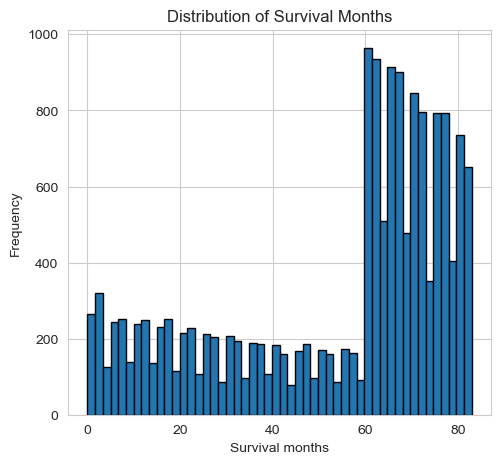

In [11]:
# Survival time distribution
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df['Survival months'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Survival Months')
plt.xlabel('Survival months')
plt.ylabel('Frequency')
plt.show()

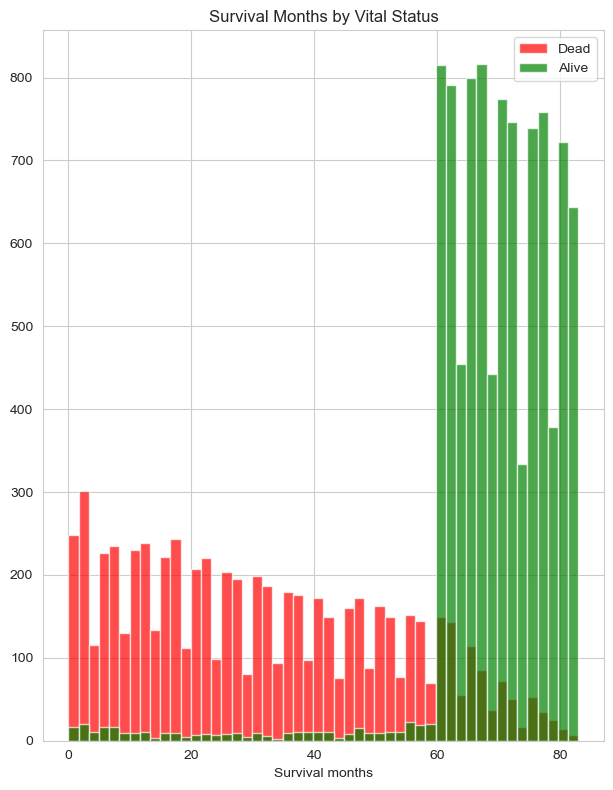

In [12]:
plt.subplot(1,2,2)
df['Survival months'][df['event']==1].hist(bins=50, color='red', alpha=0.7, label='Dead')
df['Survival months'][df['event']==0].hist(bins=50, color='green', alpha=0.7, label='Alive')
plt.title('Survival Months by Vital Status')
plt.xlabel('Survival months')
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Tumor size')

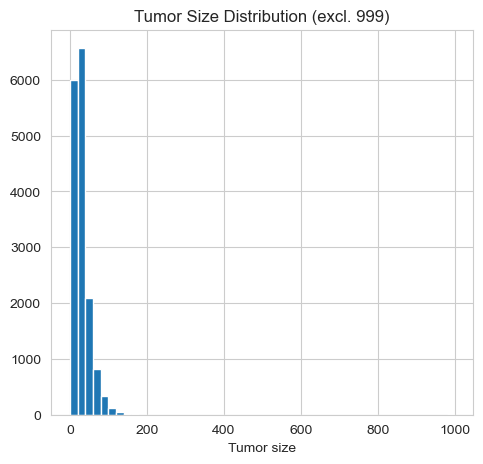

In [13]:
# Numerical features analysis: Tumor Size
# Tumor size distribution (replace 999 with NaN)
tumor = df['Tumor Size'].replace(999, np.nan)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
tumor.hist(bins=50)
plt.title('Tumor Size Distribution (excl. 999)')
plt.xlabel('Tumor size')

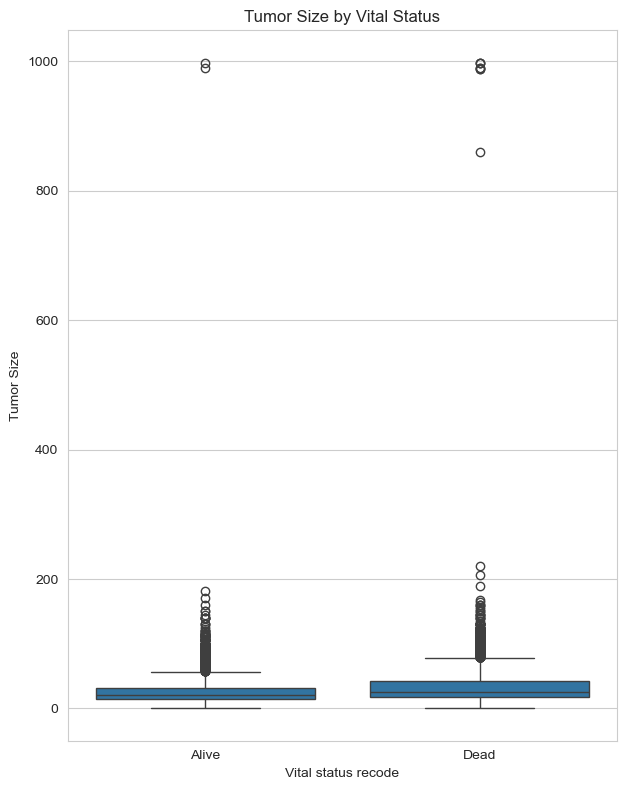

In [14]:
plt.subplot(1,2,2)
# Boxplot by vital status
df_tmp = df.copy()
df_tmp['Tumor Size'] = df_tmp['Tumor Size'].replace(999, np.nan)
sns.boxplot(data=df_tmp, x='Vital status recode', y='Tumor Size')
plt.title('Tumor Size by Vital Status')
plt.tight_layout()
plt.show()

In [15]:
T=df["Survival months"]
E=df["event"]

In [16]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 16383 total observations, 9584 right-censored observations>

In [17]:
S_t = kmf.survival_function_.values.flatten()
times = kmf.survival_function_.index.values

In [18]:
delta_S = -np.diff(S_t, prepend=1)
hazard_estimate = delta_S / S_t

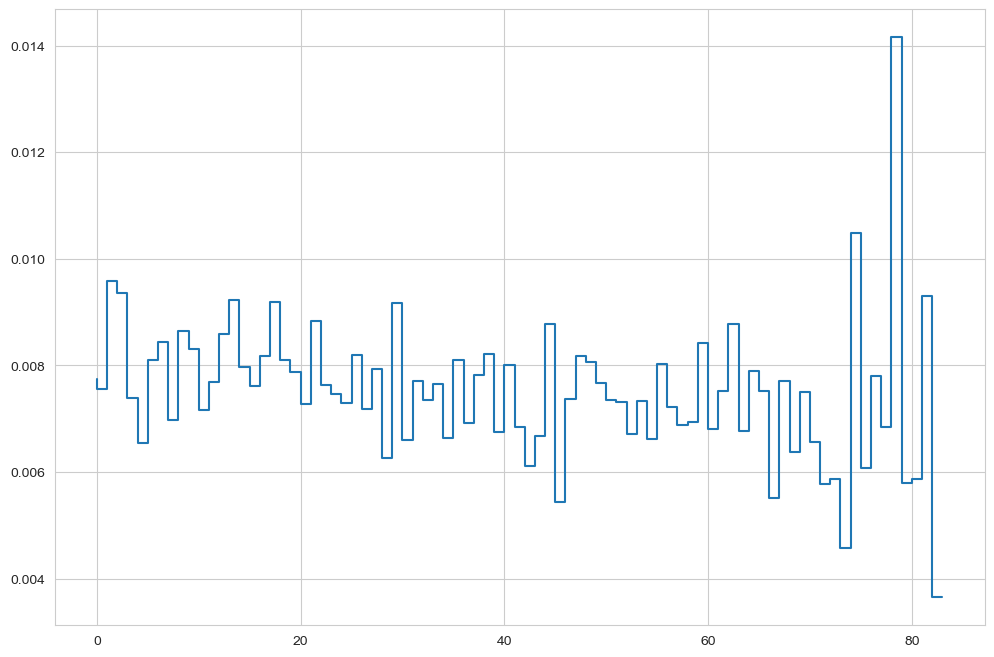

In [19]:
plt.step(times, hazard_estimate)

C:\Users\sumit\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


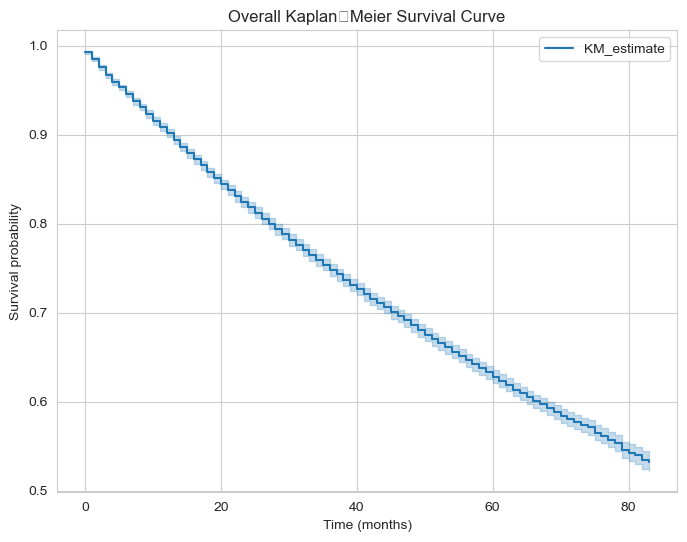

In [20]:
# Overall KM curve
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(df['Survival months'], df['event'])
plt.figure(figsize=(8,6))
kmf_overall.plot()
plt.title('Overall Kaplan‑Meier Survival Curve')
plt.xlabel('Time (months)')
plt.ylabel('Survival probability')
plt.show()

In [21]:
# Event rate
event_rate = df['event'].mean()
print(f"Proportion deceased: {event_rate:.2%}")

Proportion deceased: 41.50%


In [22]:
# 4. Kaplan‑Meier survival curves for key categorical variables
def plot_km_by_category(df, time_col, event_col, cat_col, title):
    kmf = KaplanMeierFitter()
    plt.figure(figsize=(10,6))
    for name, group in df.groupby(cat_col):
        kmf.fit(group[time_col], group[event_col], label=name)
        kmf.plot()
    plt.title(title)
    plt.xlabel('Time (months)')
    plt.ylabel('Survival probability')
    plt.legend()
    plt.show()

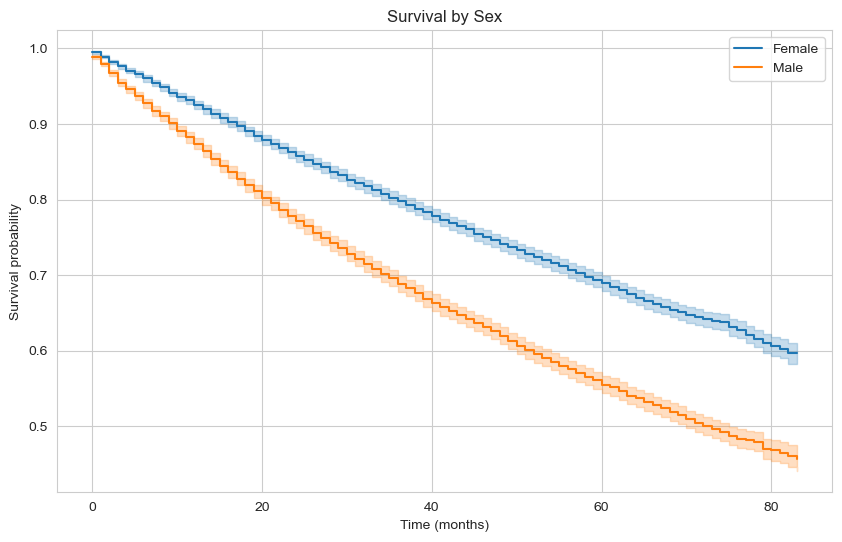

In [23]:
# By Sex
plot_km_by_category(df, 'Survival months', 'event', 'Sex', 'Survival by Sex')

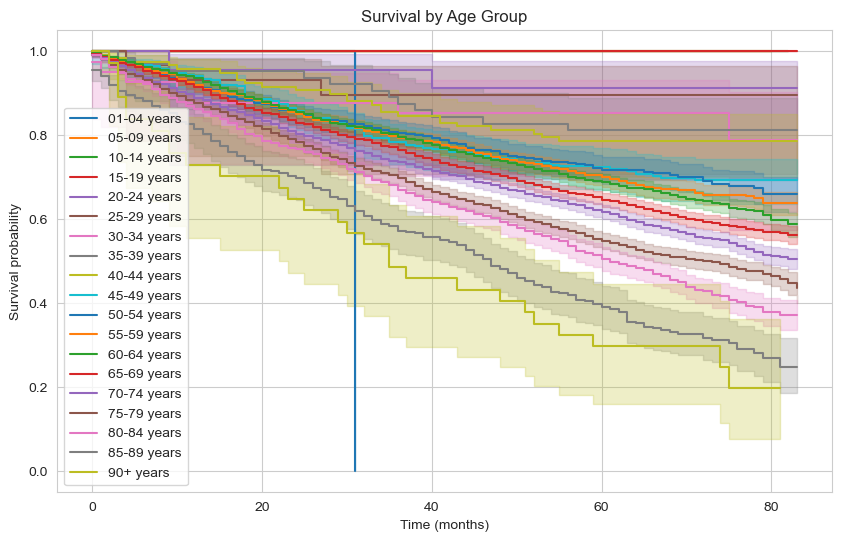

In [24]:
# By Age group (already binned)
plot_km_by_category(df, 'Survival months', 'event', 'Age recode with <1 year olds and 90+', 'Survival by Age Group')

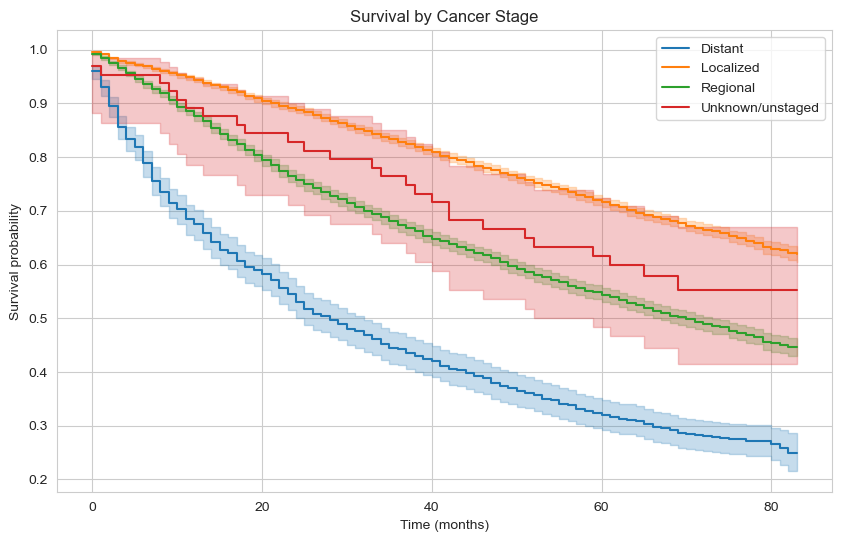

In [25]:
# By Summary stage
plot_km_by_category(df, 'Survival months', 'event', 'Summary stage', 'Survival by Cancer Stage')

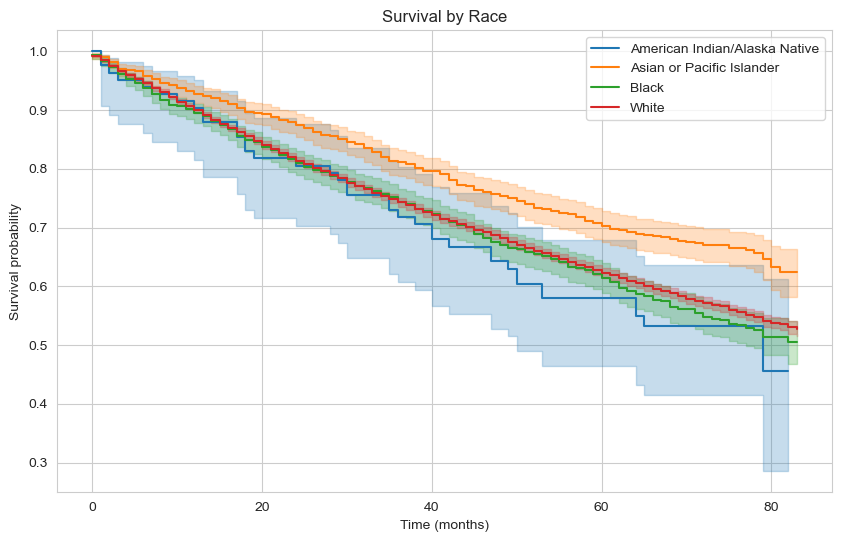

In [26]:
# By Race
plot_km_by_category(df, 'Survival months', 'event', 'Race recode (W, B, AI, API)', 'Survival by Race')

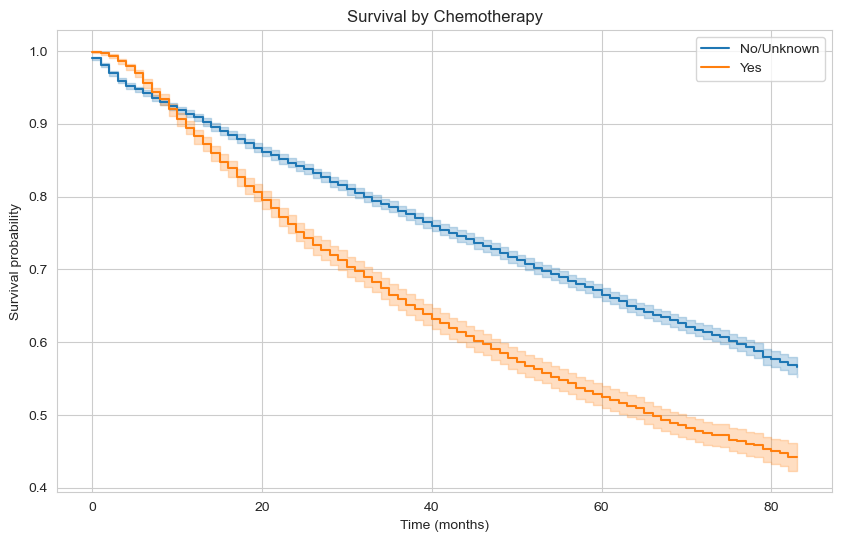

In [27]:
# By Chemotherapy recode
plot_km_by_category(df, 'Survival months', 'event', 'Chemotherapy recode', 'Survival by Chemotherapy')

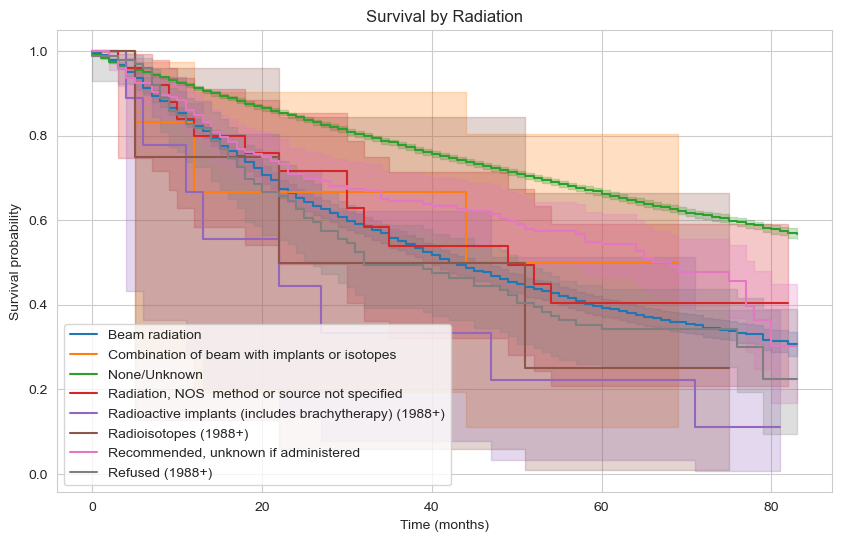

In [28]:
# By Radiation recode
plot_km_by_category(df, 'Survival months', 'event', 'Radiation recode', 'Survival by Radiation')

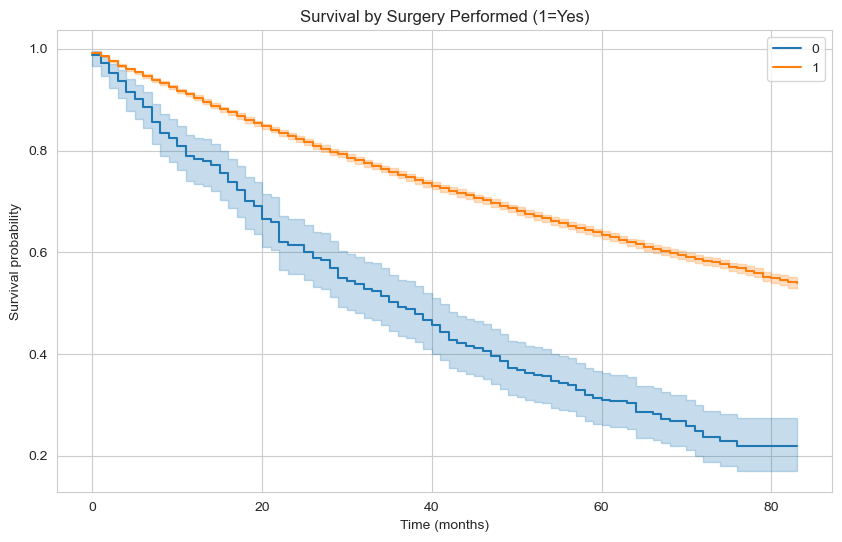

In [29]:
# By Surgery (Reason no cancer-directed surgery)
# Create a binary indicator: Surgery performed vs not
df['surgery_performed'] = (df['Reason no cancer-directed surgery'] == 'Surgery performed').astype(int)
plot_km_by_category(df, 'Survival months', 'event', 'surgery_performed', 'Survival by Surgery Performed (1=Yes)')

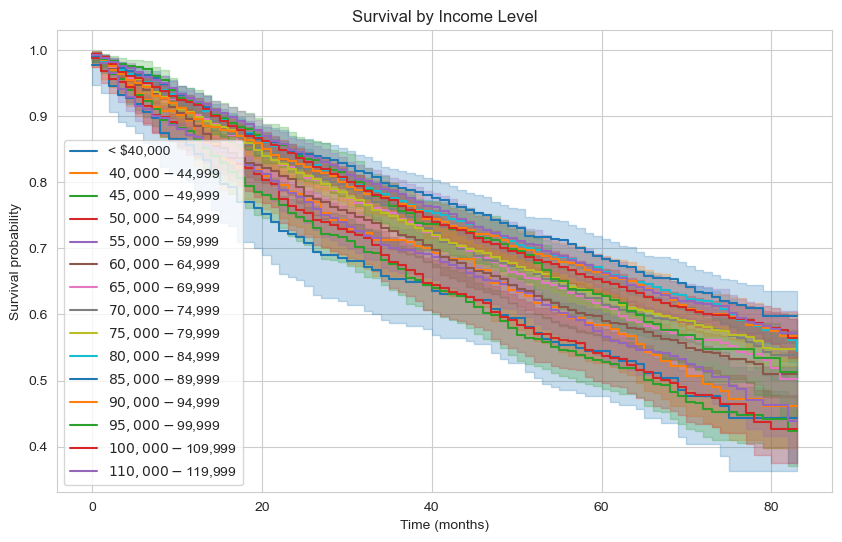

In [30]:
# Income (ordinal categories)
income_order = ['< $40,000', '$40,000 - $44,999', '$45,000 - $49,999', '$50,000 - $54,999',
                '$55,000 - $59,999', '$60,000 - $64,999', '$65,000 - $69,999', '$70,000 - $74,999',
                '$75,000 - $79,999', '$80,000 - $84,999', '$85,000 - $89,999', '$90,000 - $94,999',
                '$95,000 - $99,999', '$100,000 - $109,999', '$110,000 - $119,999']
df['income_ordered'] = pd.Categorical(df['Median household income inflation adj to 2023'],
                                        categories=income_order, ordered=True)
plot_km_by_category(df, 'Survival months', 'event', 'income_ordered', 'Survival by Income Level')

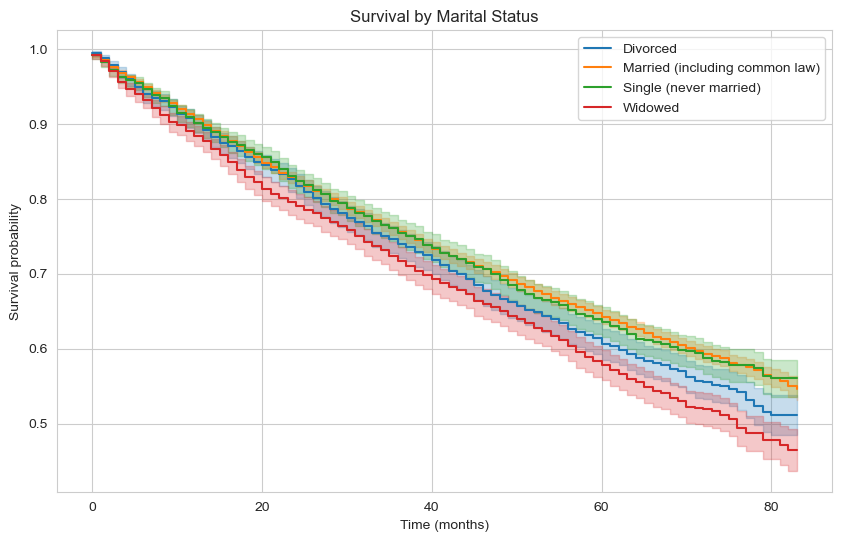

In [31]:
# Marital status
plot_km_by_category(df, 'Survival months', 'event', 'Marital status at diagnosis', 'Survival by Marital Status')

## Log-Rank Test Significance Analysis
We use the Log-Rank test to determine if there are statistically significant differences between the survival distributions of different groups.

In [32]:
from lifelines.statistics import multivariate_logrank_test

# Using the original column names as they appear in df.columns
categorical_vars = [
    'Sex', 'Age recode with <1 year olds and 90+', 'Summary stage',
    'Race recode (W, B, AI, API)', 'Chemotherapy recode',
    'Radiation recode', 'Marital status at diagnosis'
]

log_rank_results = []

for var in categorical_vars:
    mask = df[var].notnull()
    results = multivariate_logrank_test(
        df.loc[mask, 'Survival months'],
        df.loc[mask, var],
        df.loc[mask, 'event']
    )

    is_significant = "Yes" if results.p_value < 0.05 else "No"
    log_rank_results.append({
        'Variable': var,
        'p-value': results.p_value,
        'Significant (α=0.05)': is_significant
    })

results_df = pd.DataFrame(log_rank_results)
display(results_df)

,Variable,p-value,Significant (α=0.05)
0,Sex,4.508315e-77,Yes
1,Age recode with <1 year olds and 90+,2.373432e-104,Yes
2,Summary stage,4.863853e-276,Yes
3,"Race recode (W, B, AI, API)",4.703698e-09,Yes
4,Chemotherapy recode,4.819323e-61,Yes
5,Radiation recode,5.411696e-152,Yes
6,Marital status at diagnosis,1.863205e-10,Yes


In [33]:
# 6. Correlation matrix (for numeric/categorical encoded)
# Encode categorical variables as numeric for correlation
from sklearn.preprocessing import OrdinalEncoder
cols_to_encode = ['Age recode with <1 year olds and 90+', 'Sex', 'Race recode (W, B, AI, API)',
                  'Grade Recode', 'Summary stage', 'Reason no cancer-directed surgery',
                  'Radiation recode', 'Chemotherapy recode', 'Marital status at diagnosis',
                  'Median household income inflation adj to 2023']
df_encoded = df.copy()
for col in cols_to_encode:
    df_encoded[col] = OrdinalEncoder().fit_transform(df_encoded[[col]])# Add event and tumor size
df_encoded['Tumor Size'] = df_encoded['Tumor Size'].replace(999, np.nan)
df_encoded['Survival months'] = df_encoded['Survival months']
df_encoded['event'] = df_encoded['event']

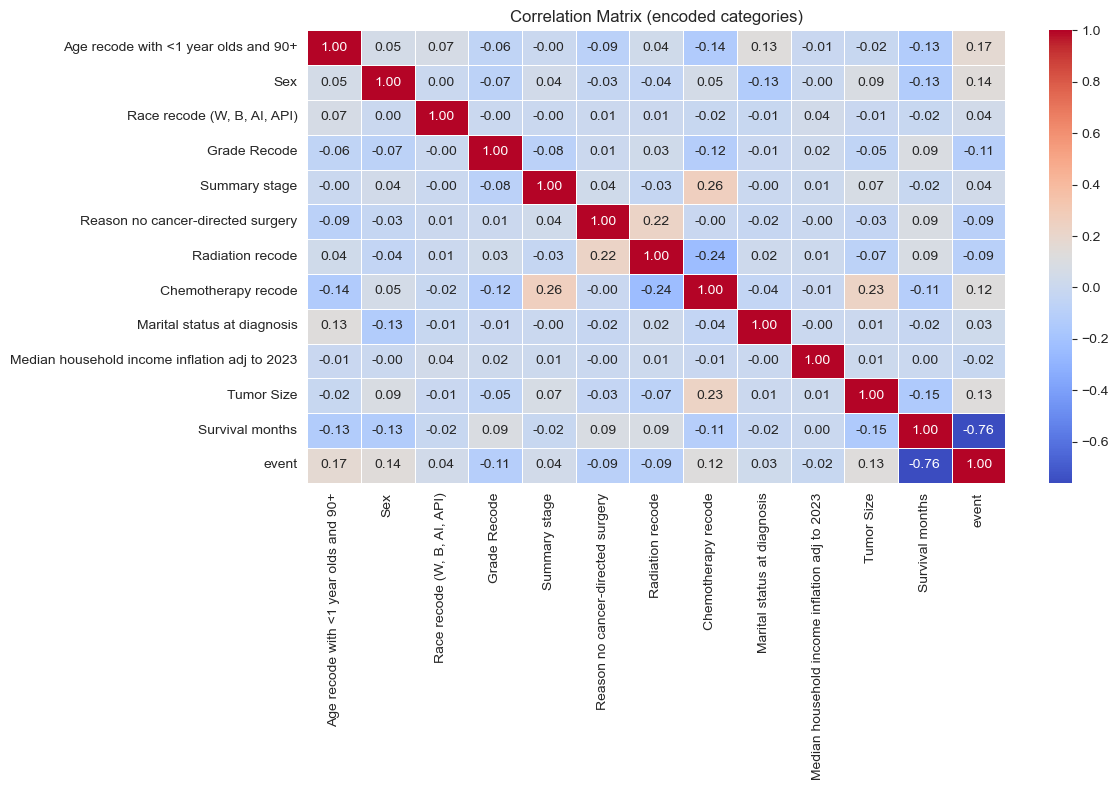

In [34]:
# Correlation matrix
corr = df_encoded[cols_to_encode + ['Tumor Size', 'Survival months', 'event']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (encoded categories)')
plt.tight_layout()
plt.show()

In [35]:
# 8. Summary of findings (printed)
print("\n=== EDA Summary ===")
print(f"Total patients: {len(df)}")
print(f"Deaths: {df['event'].sum()} ({event_rate:.1%})")
print(f"Median survival time (overall): {kmf_overall.median_survival_time_:.1f} months")
print("\nKey observations from KM curves:")
print("- Later stage (Distant) has much worse survival than Localized/Regional.")
print("- Older age groups (80+) have lower survival.")
print("- Patients who received surgery have better survival.")
print("- Chemotherapy and radiation show mixed effects, likely due to confounding by stage.")
print("- Higher income appears associated with slightly better survival (but check p-value).")


=== EDA Summary ===
Total patients: 16383
Deaths: 6799 (41.5%)
Median survival time (overall): inf months

Key observations from KM curves:
- Later stage (Distant) has much worse survival than Localized/Regional.
- Older age groups (80+) have lower survival.
- Patients who received surgery have better survival.
- Chemotherapy and radiation show mixed effects, likely due to confounding by stage.
- Higher income appears associated with slightly better survival (but check p-value).


In [36]:
# 3. Data Cleaning & Preprocessing
# Rename columns for easier handling
df.columns = df.columns.str.strip().str.replace(' ', '_')
print(df.columns.tolist())

['Age_recode_with_<1_year_olds_and_90+', 'Sex', 'Race_recode_(W,_B,_AI,_API)', 'Grade_Recode', 'Summary_stage', 'Reason_no_cancer-directed_surgery', 'Radiation_recode', 'Chemotherapy_recode', 'Tumor_Size', 'Survival_months', 'Vital_status_recode', 'Marital_status_at_diagnosis', 'Median_household_income_inflation_adj_to_2023', 'event', 'surgery_performed', 'income_ordered']


In [37]:
# Define target variables
time_col = 'Survival_months'
event_col = 'Vital_status_recode'
# Drop rows with missing time or event (should be none)
df = df.dropna(subset=[time_col, 'event'])
# For Tumor_Size, value 999 likely indicates missing/unknown -> set to NaN
df['Tumor_Size'] = df['Tumor_Size'].replace(999, np.nan)

In [38]:
# Select all features except the target columns
feature_cols = ['Age_recode_with_<1_year_olds_and_90+', 'Sex', 'Race_recode_(W,_B,_AI,_API)',
                'Grade_Recode', 'Summary_stage', 'Reason_no_cancer-directed_surgery',
                'Radiation_recode', 'Chemotherapy_recode', 'Tumor_Size',
                'Marital_status_at_diagnosis', 'Median_household_income_inflation_adj_to_2023']
# Define categorical and numerical columns
categorical_cols = [c for c in feature_cols if c not in ['Tumor_Size']]
numerical_cols = ['Tumor_Size']

In [39]:
# 4. Encode categorical variables
# We'll use ordinal encoding for tree-based model (RSF) and one‑hot encoding for Cox PH.
# For Cox we need to avoid perfect collinearity, so we'll use `pd.get_dummies` with `drop_first=True`.# Prepare data for Cox (one‑hot encoding)
X_cox = df[feature_cols].copy()
X_cox = pd.get_dummies(X_cox, columns=categorical_cols, drop_first=True)

In [40]:
# Handle missing Tumor_Size: fill with median
median_tumor = X_cox['Tumor_Size'].median()
X_cox['Tumor_Size'] = X_cox['Tumor_Size'].fillna(median_tumor)
# Train/test split (80/20)
X_train_cox, X_test_cox, T_train, T_test, E_train, E_test = train_test_split(
    X_cox, T.values, E.values, test_size=0.2, random_state=42, stratify=E
)

In [41]:
# 5. Cox Proportional Hazards Model
cph = CoxPHFitter()
train_df = X_train_cox.copy()
train_df['T'] = T_train
train_df['E'] = E_train

cph.fit(train_df, duration_col='T', event_col='E')
# Predict on test set
pred_risk_test = cph.predict_partial_hazard(X_test_cox)

In [42]:
cph.check_assumptions(train_df)
cph.print_summary()

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Summary_stage_Localized' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['Summary_stage_Localized',
...]` in the call in `.fit`. See documentation in link [E] below.

2. Variable 'Summary_stage_Regional' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['Summary_stage_Regional',
...]` in the call in `.fit`. See documentation in link [E] below.

3. Variable 'Chemotherapy_recode_Yes' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['Chemotherapy_recode_Yes',
...]` in the call in `.fit`. See documentation in link [E] below.

4. Variable 'Median_household_income_inflation_adj_to_2023_$95,000 - $99,999' failed the non-proportional test: p-value is 0.0069.

   Advice: with so few unique values (only 2), you can include
`strata=['Median_household_inco

<lifelines.CoxPHFitter: fitted with 13106 total observations, 7667 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 13106
number of events observed = 5439
   partial log-likelihood = -48644.75
         time fit was run = 2026-05-01 22:06:42 UTC

---
                                                                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                                                          
Tumor_Size                                                                         0.00      1.00      0.00            0.00            0.00                1.00                1.00
Age_recode_with_<1_year_olds_and_90+_05-09 years                                 -14.20      0.00    657.61        -1303.09         1274.70                0.00                 inf
Age_recode_with_<1_year_olds_and_90+_10-14 years                                 -14.47      0.00    681.00        -1349.20         1320.25                0.00                 inf
Age_recode_with_<1_year_olds_and_90+_15-19 years                                 -14.00      0.00    315.24         -631.86          603.86                0.00           1.79e+262
Age_recode_with_<1_year_olds_and_90+_20-24 years                                  -2.69      0.07      1.23           -5.09           -0.28                0.01                0.76
Age_recode_with_<1_year_olds_and_90+_25-29 years                                  -2.15      0.12      1.16           -4.43            0.12                0.01                1.13
Age_recode_with_<1_year_olds_and_90+_30-34 years                                  -2.02      0.13      1.12           -4.22            0.18                0.01                1.20
Age_recode_with_<1_year_olds_and_90+_35-39 years                                  -1.94      0.14      1.05           -3.99            0.12                0.02                1.13
Age_recode_with_<1_year_olds_and_90+_40-44 years                                  -1.82      0.16      1.03           -3.84            0.19                0.02                1.21
Age_recode_with_<1_year_olds_and_90+_45-49 years                                  -1.57      0.21      1.01           -3.55            0.42                0.03                1.52
Age_recode_with_<1_year_olds_and_90+_50-54 years                                  -1.59      0.20      1.01           -3.57            0.38                0.03                1.47
Age_recode_with_<1_year_olds_and_90+_55-59 years                                  -1.41      0.24      1.01           -3.38            0.56                0.03                1.76
Age_recode_with_<1_year_olds_and_90+_60-64 years                                  -1.34      0.26      1.01           -3.32            0.63                0.04                1.87
Age_recode_with_<1_year_olds_and_90+_65-69 years                                  -1.13      0.32      1.01           -3.11            0.84                0.04                2.31
Age_recode_with_<1_year_olds_and_90+_70-74 years                                  -1.01      0.36      1.01           -2.98            0.96                0.05                2.61
Age_recode_with_<1_year_olds_and_90+_75-79 years                                  -0.82      0.44      1.01           -2.79            1.15                0.06                3.17
Age_recode_with_<1_year_olds_and_90+_80-84 years                                  -0.57      0.56      1.01           -2.54            1.40                0.08                4.06
Age_recode_with_<1_year_olds_and_90+_85-89 years                                  -0.26      0.77      1.01           -2.23            1.72                0.11                5.58
Age_recode_with_<1_year_olds_and_90+_90+ y

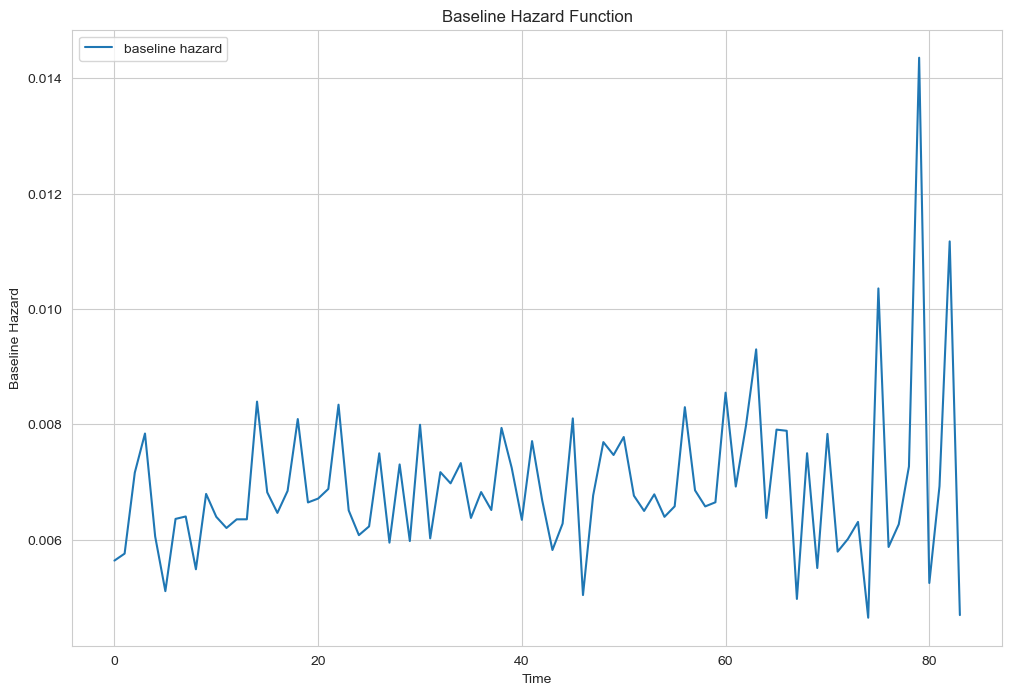

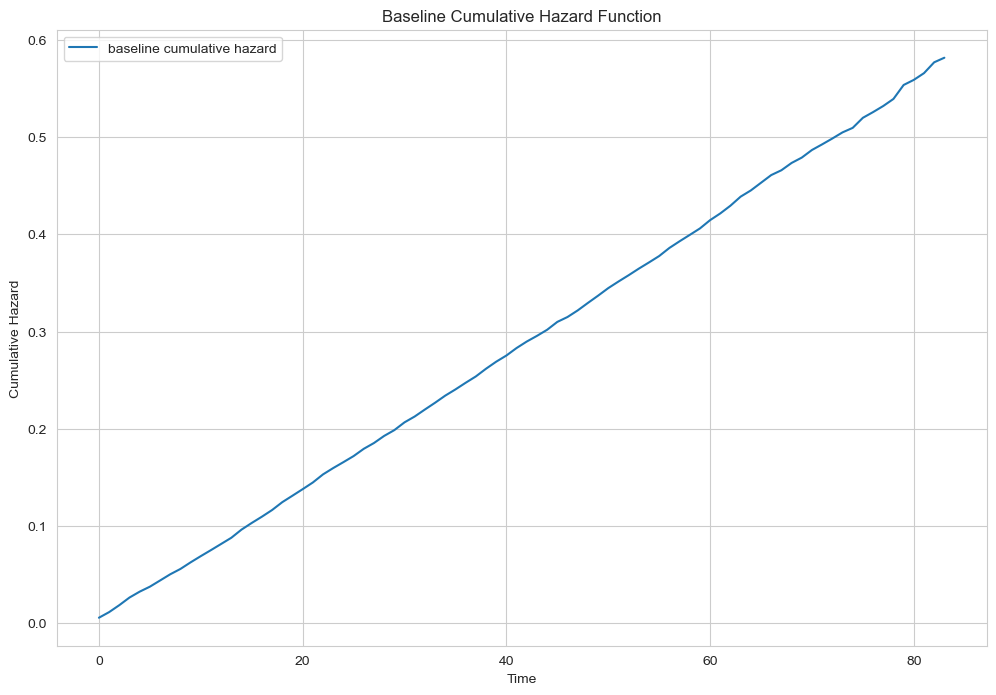

In [43]:
baseline_hazard = cph.baseline_hazard_

baseline_hazard.plot()
plt.title("Baseline Hazard Function")
plt.xlabel("Time")
plt.ylabel("Baseline Hazard")
plt.show()

In [ ]:
baseline_cumulative_hazard = cph.baseline_cumulative_hazard_

baseline_cumulative_hazard.plot()
plt.title("Baseline Cumulative Hazard Function")
plt.xlabel("Time")
plt.ylabel("Cumulative Hazard")
plt.show()

In [44]:
print(cph.hazard_ratios_)

covariate
Tumor_Size                                                                          1.001911e+00
Age_recode_with_<1_year_olds_and_90+_05-09 years                                    6.840317e-07
Age_recode_with_<1_year_olds_and_90+_10-14 years                                    5.173417e-07
Age_recode_with_<1_year_olds_and_90+_15-19 years                                    8.341482e-07
Age_recode_with_<1_year_olds_and_90+_20-24 years                                    6.816023e-02
Age_recode_with_<1_year_olds_and_90+_25-29 years                                    1.159836e-01
Age_recode_with_<1_year_olds_and_90+_30-34 years                                    1.329776e-01
Age_recode_with_<1_year_olds_and_90+_35-39 years                                    1.442986e-01
Age_recode_with_<1_year_olds_and_90+_40-44 years                                    1.614262e-01
Age_recode_with_<1_year_olds_and_90+_45-49 years                                    2.089288e-01
Age_recode_with_<1_y

In [45]:
# Extract only statistically significant covariates from the Cox model
cph_summary = cph.summary[['exp(coef)', 'p']]
significant_covariates = cph_summary[cph_summary['p'] < 0.05]

print("Statistically Significant Covariates (p < 0.05):")
display(significant_covariates.sort_values('p'))

Statistically Significant Covariates (p < 0.05):


,exp(coef),p
covariate,,
Summary_stage_Localized,0.316214,1.055228e-117
Summary_stage_Regional,0.485688,3.452205e-53
Sex_Male,1.500861,1.120527e-45
Reason_no_cancer-directed_surgery_Surgery performed,0.042458,1.761318e-24
"Reason_no_cancer-directed_surgery_Recommended but not performed, patient refused",0.048540,2.090028e-21
Radiation_recode_None/Unknown,0.687050,6.538301e-18
Tumor_Size,1.001911,4.652598e-16
"Reason_no_cancer-directed_surgery_Recommended, unknown if performed",0.061543,2.445825e-12
Marital_status_at_diagnosis_Married (including common law),0.772258,3.367745e-10


In [46]:
# For RSF we need a structured array (sksurv format) and encode categoricals differently
# Use OrdinalEncoder for categoricals to avoid too many dummy columns (trees handle it).
X_rsf = df[feature_cols].copy()
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_rsf[categorical_cols] = ord_enc.fit_transform(X_rsf[categorical_cols])
X_rsf['Tumor_Size'] = X_rsf['Tumor_Size'].fillna(median_tumor)# Train/test split for RSF
X_train_rsf, X_test_rsf, T_train_rsf, T_test_rsf, E_train_rsf, E_test_rsf = train_test_split(
    X_rsf, T.values, E.values, test_size=0.2, random_state=42, stratify=E
)

In [47]:
from sksurv.util import Surv
# Create structured array
y_train_rsf = Surv.from_arrays(E_train_rsf, T_train_rsf)
y_test_rsf = Surv.from_arrays(E_test_rsf, T_test_rsf)

In [48]:
# 6. Random Survival Forest
rsf = RandomSurvivalForest(n_estimators=260, min_samples_split=10, min_samples_leaf=20,max_depth=None,
                           max_features='sqrt', n_jobs=-1, random_state=42)
rsf.fit(X_train_rsf, y_train_rsf)

,n_estimators,260
,max_depth,None
,min_samples_split,10
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [49]:
sample_rsf_raw = df.iloc[:1].copy()

# Preprocess the sample for RSF in the same way X_rsf was prepared
sample_rsf_processed = sample_rsf_raw[feature_cols].copy()
sample_rsf_processed[categorical_cols] = ord_enc.transform(sample_rsf_processed[categorical_cols])
sample_rsf_processed['Tumor_Size'] = sample_rsf_processed['Tumor_Size'].fillna(median_tumor)

# Predict survival functions with RSF
rsf_surv_funcs = rsf.predict_survival_function(sample_rsf_processed, return_array=False)

plt.figure()

plt.step(s.x, s.y, where="post", label="RSF")

plt.title("Random Survival Forest - Predicted Survival Curves")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

NameError: name 's' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
# 7. Model Comparison & Conclusion
# --- Cox PH predictions ---
pred_risk_train = cph.predict_partial_hazard(X_train_cox)
pred_risk_test = cph.predict_partial_hazard(X_test_cox)

c_index_cph_train = concordance_index_censored(
    E_train.astype(bool), T_train, pred_risk_train
)[0]
c_index_cph_test = concordance_index_censored(
    E_test.astype(bool), T_test, pred_risk_test
)[0]

# --- RSF predictions (no negation) ---
risk_train_rsf = rsf.predict(X_train_rsf)
risk_test_rsf = rsf.predict(X_test_rsf)

c_index_rsf_train = concordance_index_censored(
    y_train_rsf["event"], y_train_rsf["time"], risk_train_rsf
)[0]
c_index_rsf_test = concordance_index_censored(
    y_test_rsf["event"], y_test_rsf["time"], risk_test_rsf
)[0]

In [ ]:
# 8. Feature importance (RSF)
result = permutation_importance(
    rsf, X_train_rsf, y_train_rsf,
    n_repeats=5, random_state=42,n_jobs=-1
)
# Extract mean importances
importances = result.importances_mean
features = X_train_rsf.columns
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,6))
plt.title('Random Survival Forest - Permutation Importances')
plt.barh(range(len(indices)), importances[indices], align='center', color="darkorange")
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# 9. Summary Table ---
print()
print("=== Full Model Performance Summary ===")
print(f"{'Model':<18} {'Split':<8} {'C-index':<12}")
print("-" *38)
print(f"{'Cox PH':<18} {'Train':<8} {c_index_cph_train:<12.4f}")
print(f"{'Cox PH':<18} {'Test':<8} {c_index_cph_test:<12.4f}")
print(f"{'RSF':<18} {'Train':<8} {c_index_rsf_train:<12.4f}")
print(f"{'RSF':<18} {'Test':<8} {c_index_rsf_test:<12.4f}")

In [ ]:
plt.figure()

# KM (overall)
kmf.fit(df['Survival_months'], df['event'], label="Kaplan-Meier")
plt.plot(kmf.survival_function_.index,
         kmf.survival_function_['Kaplan-Meier'],
         linestyle='--',label='KM')

# RSF
plt.step(s.x, s.y, where="post",label="RSF")
plt.title("KM vs Cox vs RSF Survival Comparison")
plt.xlabel("Time")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()